In [1]:
from scipy.stats import entropy
import os
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

members = pd.read_csv('/home/rb/Documents/Data/metadata/members.csv',sep='\t')


party_merge = {
    # Major traditional parties
    "VVD": "nl.p.vvd",
    "PvdA": "nl.p.pvda",
    "CDA": "nl.p.cda",
    "D66": "nl.p.d66",
    "GL": "nl.p.gl",
    "SP": "nl.p.sp",
    "SGP": "nl.p.sgp",
    "CU": "nl.p.cu",
    "PVV": "nl.p.pvv",
    "PvdD": "nl.p.pvdd",

    # 50PLUS variants
    "50PLUS": "nl.p.50plus",
    "50PLUS;Den Haan": "nl.p.50plus",
    "Krol": "nl.p.50plus",

    # ChristenUnie / predecessors already covered via CU
    "OSF": "nl.p.osf",

    # Newer parties
    "DENK": "nl.p.denk",
    "DENK;GKÖ": "nl.p.denk",
    "FvD": "nl.p.fvd",
    "BBB": "nl.p.bbb",
    "BIJ1": "nl.p.bij1",
    "JA21": "nl.p.ja21",
    "VOLT": "nl.p.volt",

    # One-person or splinter parties → existing groups
    "Bontes/Van Klaveren": "nl.p.groepbontesvanklaveren",
    "GKVK": "nl.p.groepbontesvanklaveren",
    "Van Vliet": "nl.p.vka",
    "vKA": "nl.p.vka",
    "Van Kooten-Arissen": "nl.p.vankootenarissen",
    "Van Haga": "nl.p.vanhaga",
    "Omtzigt": "nl.p.omtzigt",

    # Monasch
    "Monasch": "nl.p.monasch",
    "Monasch;Nieuwe Wegen": "nl.p.monasch",

    # Independents / unclear but consistent
    "Klein": "nl.p.klein",
    "Houwers": "nl.p.houwers",
    "vanPareren": "nl.p.vanpareren",

    # Explicit missing / placeholder
    "-": None,
}

def distinctive_topics(df, period, top_n=10, keys_dict=None, method="2a", alpha=100):
    """
    df       : DataFrame with DateTimeIndex or 'YYYYQx'
    period   : '1946Q2', 1946, or 1940 (decade)
    method : {"2a", "2b", "3"}
        Bias-correction method:
        - "2a": Normalized difference (|p - q| / q). Down-weights rare topics.
        - "2b": Bayesian shrinkage toward global mean. Smooths noisy small values.
        - "3" : Signal-to-noise ratio. Rewards differences larger than expected noise.
    alpha : float
        Shrinkage strength for method="2b" (higher = stronger shrinkage).
    alpha    : shrinkage strength for method="2b"
    """

    keys_dict = keys_dict or {}

    # Determine subset
    if isinstance(period, str) and "Q" in period:
        subset = df.loc[[period]]
    elif isinstance(period, int) and period % 10 != 0:
        subset = df[df.index.year == period]
    elif isinstance(period, int) and period % 10 == 0:
        subset = df[(df.index.year // 10) * 10 == period]
    else:
        raise ValueError("Period must be quarter 'YYYYQx', year YYYY, or decade YYYY.")

    target = subset.mean()
    overall = df.mean()

    # ---- scoring methods ----
    if method == "2a":
        # normalized difference
        score = (target - overall).abs() / (overall + 1e-12)

    elif method == "2b":
        # Bayesian shrinkage toward global mean
        shrunk = (target * alpha + overall) / (alpha + 1)
        score = (shrunk - overall).abs()

    elif method == "3":
        # Signal-to-noise ratio
        N_period = len(subset)
        noise = np.sqrt(overall * (1 - overall) / max(N_period, 1))
        score = (target - overall).abs() / (noise + 1e-12)

    else:
        raise ValueError("method must be '2a', '2b', or '3'")

    # Map keys as requested
    labels = [
        f"{int(i)} {keys_dict.get(int(i), '')[:50]}"
        for i in df.columns
    ]

    return (
        pd.Series(score.values, index=labels)
          .sort_values(ascending=False)
          .head(top_n)
    )

In [2]:
control_topics = [78,100,253,88,317,194]

In [3]:
df = pd.read_csv('/home/rb/Downloads/lda/lda/data-1945-2022-chunked/averaged_topics.csv')
kd = pd.read_csv('/home/rb/Downloads/lda/lda/data-1945-2022-chunked/topic-keys.txt',sep='\t',header=None)
ks = dict(zip(kd[0],kd[2]))
dfd = df.drop(columns=['member_or_speaker','party-ref'])
dfd.index = pd.to_datetime(df.date).dt.to_period('D')
dfd = dfd.drop(columns=['date']).groupby(dfd.index).mean()
df = df.drop(columns=['member_or_speaker','party-ref'])

FileNotFoundError: [Errno 2] No such file or directory: '/home/rb/Downloads/lda/lda/data-1945-2022-chunked/averaged_topics.csv'

# Analysis of Control Topics

In [5]:
labeld = {str(k):" ".join(v.split(' ')[:8]) for k,v in ks.items()}

In [3]:
ks[88]

NameError: name 'ks' is not defined

In [6]:
[(k,v) for k,v in ks.items() if "controle" in v or "evaluatie " in v]

[(47,
  'keuring paard wagen warenwet controle eend keuringsdienst periodiek bedrijfsleven garage volksgezondheid bijten vreemd dienst garagebedrijf vleeskeuring goed vlees belang voorbeeld '),
 (63,
  'experiment vernieuwing sociaal gemeente beleid breed project kader experimenteel resultaat voorzitter nieuw evaluatie ervaring vorm gebied grotestedenbeleid ruimte jaar positief '),
 (78,
  'controle financieel verantwoording jaarverslag goed beheer doelmatigheid extern kamer financiën administratie departement administratief automatisering informatie intern zaak inzicht uitvoering punt '),
 (100,
  'inspectie toezicht goed rol taak inspecteur kwaliteit rapport onafhankelijk instelling onderzoek controle orde ministerie veiligheid voldoende organisatie werk handhaving melding '),
 (108,
  'dienst veiligheidsdienst informatie veiligheid geheim minister taak inlichtingendienst beveiliging bevoegdheid gegeven controle journalist persoon staat activiteit werk wet dreiging vraag '),
 (183,
 

In [15]:
plt.rcParams['font.family'] = 'Source Sans Pro'
plt.rcParams['font.size'] = 12

import seaborn as sns

sns.set_palette("Paired")

In [16]:
diac = dfd.groupby(dfd.index.year).mean().ewm(span=4).mean()

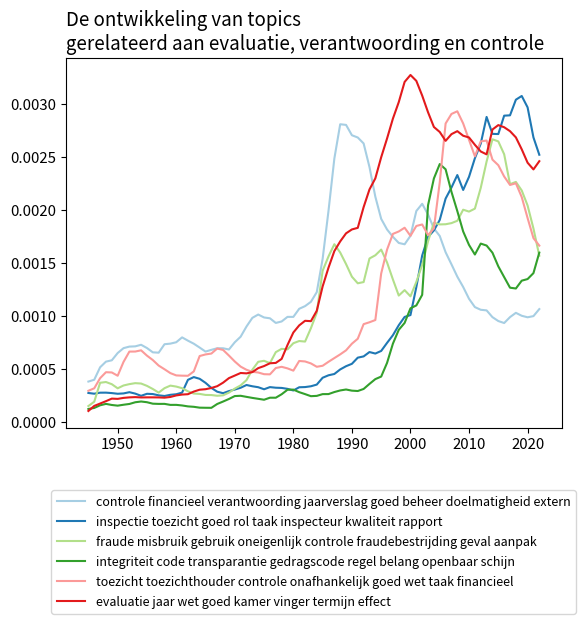

In [17]:
f,a = plt.subplots()

for ct in control_topics:
    a.plot(diac.index, diac[str(ct)].ewm(span=4).mean(), label=labeld[str(ct)])

a.legend(loc='upper center',bbox_to_anchor=(.5,-.15), fontsize=10)
a.set_title("De ontwikkeling van topics\ngerelateerd aan evaluatie, verantwoording en controle", loc="left", fontsize=15)

plt.savefig('results/figs/control-topics.png',dpi=400,bbox_inches='tight')

In [35]:
diac.loc[1980:1990].mean().loc[['78','194','253']] / diac.loc[1970:1980].mean().loc[['78','194','253']]

78     2.082804
194    2.350232
253    2.126115
dtype: float64

In [192]:
df = pd.read_csv('/home/rb/Downloads/lda/lda/data-1945-2022-chunked/averaged_topics.csv')
df['date'] = pd.to_datetime(df['date'])
df['party-ref'] = df['party-ref'].apply(lambda p: party_merge[p] if p in party_merge else p)

In [193]:
parties = dict(zip(df['member_or_speaker'], df['party-ref']))
names = dict(zip(members['resolver-url'].str.split('/').str[3].str.split('?').str[0], members.name))

In [194]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp
from scipy.special import erfc

def significant_topic_speakers(df, start_year, end_year, topic_k, p_threshold=0.05,
                               top_n=10, min_observations=3, min_effect_size=0.05,
                               multiple_test_correction='bonferroni'):
    """
    Identify speakers who use a given topic significantly more than others in a specified period.

    Parameters:
    - df: DataFrame with columns 'member_or_speaker', 'date', and topic columns as strings ('0', '1', ...)
    - start_year, end_year: integers specifying the period
    - topic_k: string, the topic number (e.g., '42')
    - p_threshold: significance threshold for p-value (default 0.05)
    - top_n: number of top speakers to return (default 10)
    - min_observations: minimum number of observations per speaker (default 3)
    - min_effect_size: minimum mean absolute deviation to report (default 0.05)
    - multiple_test_correction: 'bonferroni', 'sidak', or None (default 'bonferroni')

    Returns:
    - DataFrame of speakers with mean deviation, t-statistic, p-value, observation count, and effect size
    """
    # Ensure date is datetime
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    # Filter period
    mask = (df['date'].dt.year >= start_year) & (df['date'].dt.year <= end_year)
    df_period = df.loc[mask].copy()

    # Compute daily mean of the topic
    df_period['daily_mean'] = df_period.groupby('date')[topic_k].transform('mean')

    # Compute daily deviation
    df_period['daily_dev'] = df_period[topic_k] - df_period['daily_mean']

    # Aggregate daily deviations per speaker
    speaker_devs = df_period.groupby('member_or_speaker')['daily_dev'].apply(list)

    # Perform one-sample t-test per speaker
    results = []

    for speaker, devs in speaker_devs.items():
        n_obs = len(devs)

        # Filter by minimum observations
        if n_obs < min_observations:
            continue

        mean_dev = np.mean(devs)

        # Filter by minimum effect size
        if abs(mean_dev) < min_effect_size:
            continue

        # Perform t-test only for positive deviations (speakers using topic more)
        if mean_dev > 0:
            t_stat, p_value = ttest_1samp(devs, 0)
        else:
            # Still compute for completeness, but you may want to skip negative deviations
            t_stat, p_value = ttest_1samp(devs, 0)

        std_dev = np.std(devs, ddof=1) if n_obs > 1 else 0
        std_error = std_dev / np.sqrt(n_obs)

        results.append({
            'speaker': speaker,
            'mean_dev': mean_dev,
            't_stat': t_stat,
            'p_value': p_value,
            'n_observations': n_obs,
            'std_dev': std_dev,
            'std_error': std_error,
            'effect_size_cohens_d': mean_dev / std_dev if std_dev > 0 else 0
        })

    if not results:
        print('no results')
        return pd.DataFrame()

    results_df = pd.DataFrame(results)

    # Filter by significance
    # results_df = results_df[results_df['p_value_corrected'] < corrected_threshold]

    # # Sort by t-statistic descending (higher deviations first)
    # results_df = results_df.sort_values('t_stat', ascending=False)

    # Return top_n speakers
    return results_df

In [207]:
r = significant_topic_speakers(df, 1982, 1985, "78", min_observations=10,min_effect_size=0)
r['party'] = r.speaker.map(parties)
r['name'] = r.speaker.map(names)
r[r.mean_dev > 0].nsmallest(15,"p_value").drop(columns=['speaker','t_stat'])

,mean_dev,p_value,n_observations,std_dev,std_error,effect_size_cohens_d,party,name
193,0.007484,0.021468,52,0.022745,0.003154,0.329033,nl.p.vvd,H.F. (Hans) Dijkstal
197,0.006684,0.031414,26,0.014949,0.002932,0.447111,nl.p.vvd,Drs. M.M.H. (Margreet) Kamp
102,0.003510,0.041942,137,0.020007,0.001709,0.175441,nl.p.d66,Drs. M.B. (Maarten) Engwirda
181,0.010015,0.049409,50,0.035144,0.004970,0.284963,nl.p.pvda,R.P. (Rein) Hummel
84,0.001232,0.080038,126,0.007834,0.000698,0.157222,nl.p.d66,Mr. E.K. (Elida) Tuinstra
79,0.015702,0.090536,24,0.043538,0.008887,0.360641,nl.p.cda,Mr. G. (Gerard) van Muiden
70,0.006149,0.098735,39,0.022690,0.003633,0.271017,nl.p.cda,Dr. S. (Sytze) Faber
90,0.001675,0.101789,32,0.005620,0.000994,0.298089,nl.p.vvd,Mr.Ir. H. (Henk) Heijne Makkreel
58,0.007895,0.110165,20,0.021070,0.004711,0.374710,nl.p.vvd,Dr. G. (Guus) Zoutendijk
108,0.001578,0.116415,37,0.005966,0.000981,0.264471,nl.p.cda,Drs. G. (Gerrit) Gerritse


In [208]:
from matplotlib.patches import Rectangle

In [240]:
[(k,v) for k,v in ks.items() if 'vervuil' in v]

[(161,
  'sanering bodem bodemsanering geval grond bodembescherming kost vervuiling overheid verontreiniging provincie wet financieel interimwet vervuiler ernstig bodemverontreiniging bedrijf milieu milieubeheer '),
 (234,
  'milieu afval minister milieubeleid chemisch stof milieuhygiëne luchtverontreiniging afvalstof milieubeheer voorbeeld beleid bedrijf handhaving probleem volksgezondheid vervuiling hergebruik maatregel verwerking '),
 (377,
  'water oppervlaktewater grondwater verontreiniging drinkwater lozing waterstaat vervuiling verkeer waterschapep kwaliteit drinkwatervoorziening waterbeheer waterhuishouding groot stof rivier provincie afvalwater vervuiler '),
 (407,
  'heffing belasting opbrengst algemeen middel tarief vervuiler grondslag kost milieu milieubeleid bedrijf principe financiering milieuheffing effect bestemmingsheffing verhoging direct financieel ')]

In [235]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def plot_party_deviation(
    df,
    tp,
    year_min=1975,
    year_max=8999,
    max_na=35,
    figsize=(12, 4),
    cmap_name='tab20b'
):
    # =========================
    # 1. Build deviations
    # =========================
    dev = df[['member_or_speaker', 'party-ref', 'date', tp]].copy()

    dev['dat_avg'] = dev.groupby('date')[tp].transform('mean')
    dev['dat_std'] = dev.groupby('date')[tp].transform('std')

    dev['dff'] = dev[tp] - dev['dat_avg']
    dev['dfz'] = dev['dff'] / dev['dat_std']

    dvp = (
        dev
        .groupby([dev.date.dt.to_period('Y'), 'party-ref'])['dff']
        .mean()
        .unstack()
    )

    # =========================
    # 2. Filter years & parties
    # =========================
    dat = dvp[(dvp.index.year > year_min) & (dvp.index.year < year_max)]

    pts = dat.apply(lambda x: x.isna().sum())
    pts = pts[pts < max_na].index.tolist()
    dat = dat[pts]

    # =========================
    # 3. FIXED party → color map
    # =========================
    cmap = plt.get_cmap(cmap_name)
    parties = list(dat.columns)

    color_map = {
        party: cmap(i % cmap.N)
        for i, party in enumerate(parties)
    }

    # =========================
    # 4. Overall contribution
    # =========================
    overall = dat.sum().sort_values()

    # =========================
    # 5. Figure layout
    # =========================
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 4, figure=fig, wspace=0.15)

    ax_ts = fig.add_subplot(gs[:, :3])
    ax_bar = fig.add_subplot(gs[:, 3])

    # =========================
    # 6. Stacked bar over time
    # =========================
    dat.plot(
        kind='bar',
        stacked=True,
        ax=ax_ts,
        color=[color_map[p] for p in dat.columns],
        legend=False
    )

    ax_ts.axhline(0, color='black', lw=1)
    ax_ts.axhspan(
        ax_ts.get_ylim()[0],
        0,
        facecolor='lightgray',
        alpha=0.75
    )

    ax_ts.set_xlabel('')
    ax_ts.set_ylabel('')

    # =========================
    # 7. Horizontal ranking bar
    # =========================
    ax_bar.barh(
        overall.index,
        overall.values,
        color=[color_map[p] for p in overall.index]
    )

    ax_bar.set_title('Overall contribution')
    ax_bar.set_xlabel('')
    ax_bar.set_ylabel('')
    ax_bar.tick_params(axis='y', labelsize=8)
    ax_bar.yaxis.tick_right()

    # =========================
    # 8. Clean spines
    # =========================
    for spine in ['top', 'right']:
        ax_ts.spines[spine].set_visible(False)
        ax_bar.spines[spine].set_visible(False)

    return fig, (ax_ts, ax_bar)


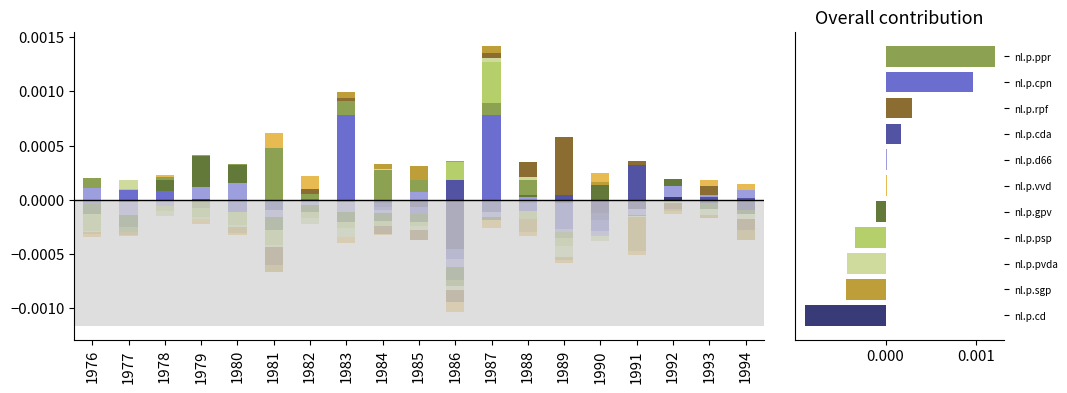

In [243]:
fig, axes = plot_party_deviation(df, tp="409", year_max=1995, max_na=12)
plt.show()

# Indexed Time

In [4]:
import seaborn as sns
from scipy.stats import zscore

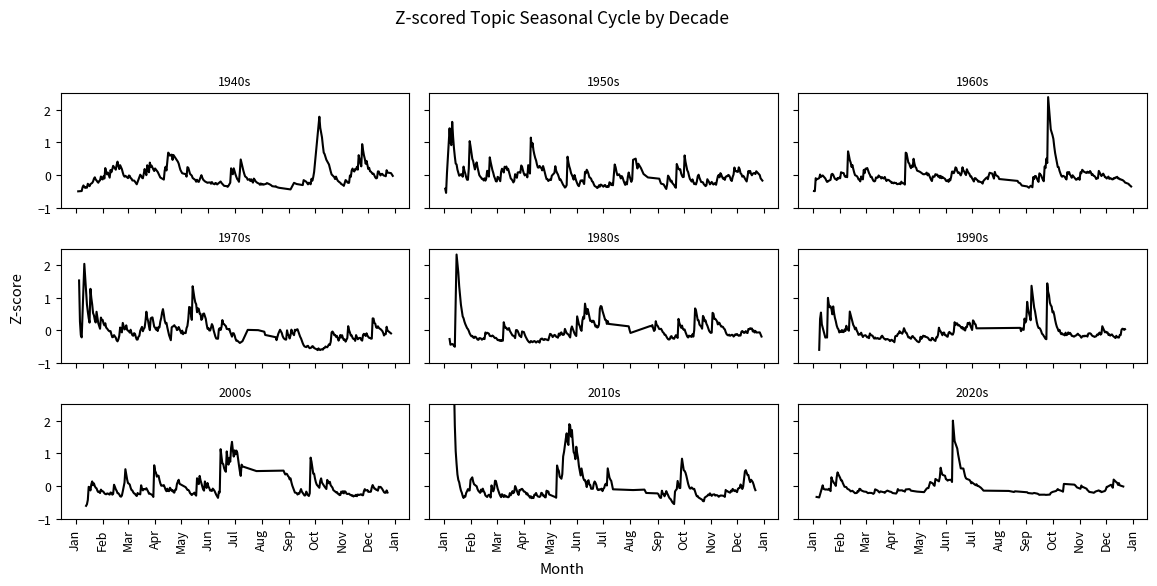

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import zscore
import pandas as pd

# ---- Set Source Sans Pro ----
plt.rcParams['font.family'] = 'Source Sans Pro'
plt.rcParams['font.sans-serif'] = ['Source Sans Pro']

# dfy must keep datetime index
dfy = dfd.copy()            # <-- remove .mean() (it destroys the datetime index)

f, a = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(12, 6))
axs = a.flatten()

c = 0
for dec, dat in dfy.groupby(dfy.index.year // 10 * 10):

    # Group by month/day
    dat2 = dat.groupby([dat.index.month, dat.index.day])[
        [str(i) for i in range(500)]
    ].mean()

    # Build valid dummy dates in year 2000
    dat2.index = pd.to_datetime(
        {
            "year": 2000,
            "month": dat2.index.get_level_values(0),
            "day": dat2.index.get_level_values(1),
        },
        errors="coerce"             # prevents invalid dates
    ).dropna()

    axs[c].plot(
        dat2.index,
        pd.Series(zscore(dat2["78"])).ewm(span=12).mean(),
        color="black"
    )
    axs[c].set_title(f"{dec}s", fontsize=10)
    axs[c].set_ylim(-1,2.5)
    c += 1

# --- Month ticks ---
for ax in axs:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.setp(ax.get_xticklabels(), rotation=90)

# --- Shared labels ---
f.suptitle(f"Z-scored Topic Seasonal Cycle by Decade", fontsize=14)
f.text(0.5, 0.04, "Month", ha="center", fontsize=12)
f.text(0.04, 0.5, "Z-score", va="center", rotation="vertical", fontsize=12)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.savefig("results/figs/topic-78-decade.png",bbox_inches="tight", dpi=500)
plt.show()


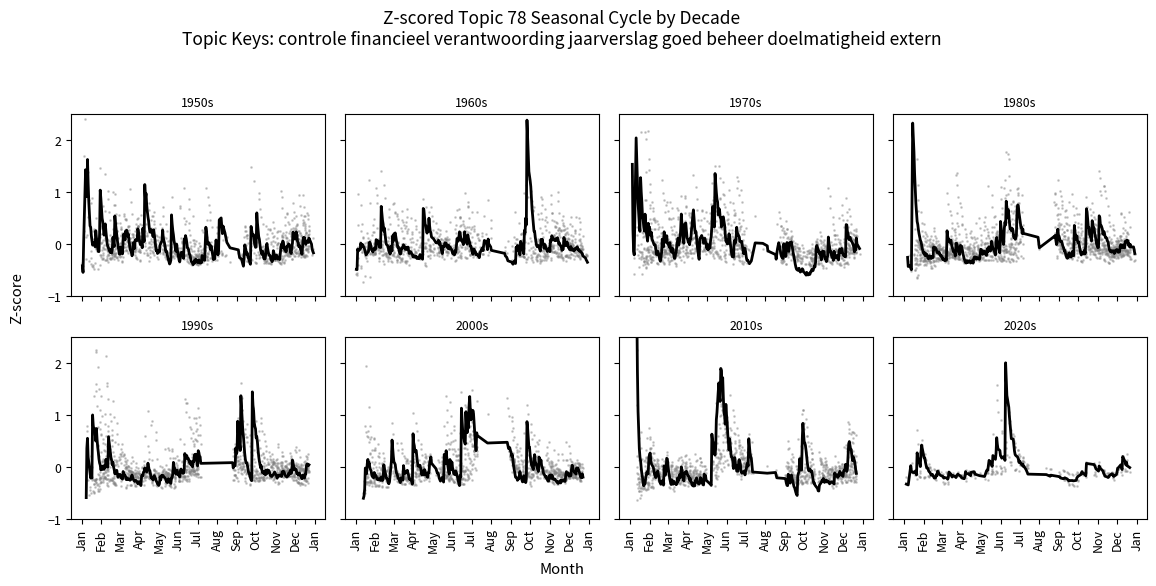

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import zscore
import pandas as pd

# ---- Set Source Sans Pro ----
plt.rcParams['font.family'] = 'Source Sans Pro'
plt.rcParams['font.sans-serif'] = ['Source Sans Pro']

# dfy must keep datetime index
dfy = dfd.copy()   # keep full datetime index
dfy = dfy[dfy.index.year>1949]

# ---- Figure layout ----
f, a = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(12, 6))
axs = a.flatten()

c = 0
for dec, dat in dfy.groupby(dfy.index.year // 10 * 10):

    ax = axs[c]
    ax.set_title(f"{dec}s", fontsize=10)

    # ---- Plot EACH YEAR in the decade ----
    for yr, dat_yr in dat.groupby(dat.index.year):

        # Build month/day per-year seasonal cycle
        dat2 = dat_yr.groupby([dat_yr.index.month, dat_yr.index.day])[
            [str(i) for i in range(500)]
        ].mean()

        # Dummy dates in year 2000
        dat2.index = pd.to_datetime(
            {
                "year": 2000,
                "month": dat2.index.get_level_values(0),
                "day": dat2.index.get_level_values(1),
            },
            errors="coerce",
        ).dropna()

        # Plot each year's line (transparent gray)
        ax.scatter(
            dat2.index,
            pd.Series(zscore(dat2["78"])).ewm(span=12).mean(),
            alpha=0.35,
            # linewidth=1,
            s=1,
            color="gray",
        )

    # ---- Plot decade mean (bold black) ----
    dec_mean = (
        dat.groupby([dat.index.month, dat.index.day])[["78"]].mean()
    )

    dec_mean.index = pd.to_datetime(
        {
            "year": 2000,
            "month": dec_mean.index.get_level_values(0),
            "day": dec_mean.index.get_level_values(1),
        },
        errors="coerce",
    ).dropna()

    ax.plot(
        dec_mean.index,
        pd.Series(zscore(dec_mean["78"])).ewm(span=12).mean(),
        color="black",
        linewidth=2,
    )

    ax.set_ylim(-1, 2.5)
    c += 1

# --- Month ticks ---
for ax in axs:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.setp(ax.get_xticklabels(), rotation=90)

# --- Shared labels ---
f.suptitle("Z-scored Topic 78 Seasonal Cycle by Decade\nTopic Keys: " + " ".join(ks[78].split(" ")[:8]), fontsize=14)
f.text(0.5, 0.04, "Month", ha="center", fontsize=12)
f.text(0.04, 0.5, "Z-score", va="center", rotation="vertical", fontsize=12)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.savefig("results/figs/topic-78-decade.png", bbox_inches="tight", dpi=500)
plt.show()


# Verantwoordingsdag

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests


In [13]:
# build a date range covering all years you need
years = range(2000, dfd.index.year.max() + 1)

third_wednesdays = []
for y in years:
    may = pd.date_range(f"{y}-05-01", f"{y}-05-31", freq="D")
    wednesdays = may[may.weekday == 2]     # Monday=0 ... Wednesday=2
    if len(wednesdays) >= 3:
        third_wednesdays.append(wednesdays[2])

third_wednesdays = pd.to_datetime(third_wednesdays).to_period('D')

df_3rd_wed_may = dfd.loc[dfd.index.isin(third_wednesdays)]

# global mean and std by topic
global_mean = dfd[dfd.index.year>1999].mean()
global_std = dfd[dfd.index.year>1999].std()

# mean for 3rd Wednesdays of May
special_mean = df_3rd_wed_may.mean()

# z-score difference
z_diff = (special_mean - global_mean) / global_std

# sort topics by distinctiveness
distinctive_topics = z_diff.sort_values(ascending=False)
distinctive_topics.index = distinctive_topics.index.astype(int).map(ks)
distinctive_topics.head(20)   # top 20 distinctive topics

integriteit code transparantie gedragscode regel belang openbaar schijn gift belangenverstrengeling nevenfunctie functie ambtenaar transparant sponsoring corruptie kamerlid onafhankelijkheid spraak bedrijf                     1.509626
nota aanleiding verslag eindverslag vraag wijziging fractie nader opmerking memorie voorlopig duidelijk toelichting antwoord stuk geval pagina mening schriftelijk bladzijde                                                      1.500771
richtlijn europees wetgeving nederlands lidstaat implementatie nationaal regelgeving verordening regel land punt niveau vraag geval toepassing kop harmonisatie verband bescherming                                               1.072063
alternatief proef dierproef aantal mogelijkheid onderzoek proefdi gebruik geneeswijs dier regulier dierproeov methode aap plan voorwaarde bereid vervanging experiment resultaat                                                  0.958014
land mensenrechten regering nederlands mensenrecht minister 

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp

def topic_distinctiveness_window(df, target_year, target_month, target_day):
    """
    Compute topic distinctiveness for the week containing the target date.
    Reference distribution = ±6 months around that week.

    df must contain column 'date' and topic columns 0..499.
    """

    # Ensure timestamp
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    target = pd.Timestamp(year=target_year, month=target_month, day=target_day)

    # ---- 1. Determine target week ----
    week_start = target - pd.Timedelta(days=target.weekday())     # Monday
    week_end   = week_start + pd.Timedelta(days=6)

    week_df = df[(df['date'] >= week_start) & (df['date'] <= week_end)]

    # Average topic distribution over that week
    week_vec = week_df[list(range(500))].mean()

    # ---- 2. Determine reference window: ±6 months around the week ----
    ref_start = week_start - pd.DateOffset(months=6)
    ref_end   = week_end   + pd.DateOffset(months=6)

    ref_df = df[(df['date'] >= ref_start) & (df['date'] <= ref_end)]
    ref_df = ref_df[list(range(500))]

    # ---- 3. Compute stats ----
    ref_mean = ref_df.mean()
    ref_std  = ref_df.std()

    # z-score (vectorized)
    z = (week_vec - ref_mean) / ref_std

    # p-values from one-sample t-test against week_vec
    tstat, pvals = ttest_1samp(ref_df, week_vec)

    # ---- 4. Build output df ----
    out = pd.DataFrame({
        "topic": ref_df.columns.astype(int),
        "week_value": week_vec.values,
        "ref_mean": ref_mean.values,
        "ref_std": ref_std.values,
        "z": z.values,
        "p": pvals
    })
    return out


In [95]:
results = []

for day in third_wednesdays:
    y, m, d = day.year, day.month, day.day
    dfr = topic_distinctiveness_window(df.rename(columns={str(i):i for i in range(500)}), y, m, d)
    dfr['label'] = dfr.topic.map(ks).str[:100]
    print(day)

    r = dfr.nsmallest(5,'z')
    for i,rr in r.iterrows():
        print('\t', rr['label'])

2000-05-17
	 amendement wet stuk wetsvoorstel punt heer termijn mevrouw goed kamer voorzitter geval mogelijkheid 
	 middel financieel extra beschikbaar geld financiering budget prioriteit jaar begroting nodig ruimte 
	 minister nieuw deur goed open jaar nodig bereid voorzitter groot stok tijd kamer zaak kans plan woor
	 situatie geval mogelijkheid ruimte heel goed vraag juridisch praktijk moment individueel echt spraak
	 motie kamer regering orde dag beraadslaging lid voorzitter voldoende mening termijn oordeel uitspraa
2001-05-16
	 groot zaak goed tijd feit laat gevolg geval hand duidelijk wijze werkelijk ernstig indruk woord moei
	 kritiek kritisch politiek reactie analyse groot beeld probleem voorbeeld terecht laat eigenlijk kenn
	 regering vraag antwoord punt mening standpunt duidelijk zaak bereid geval nodig oordeel nader aanzie
	 heel gesprek goed vraag echt heer natuurlijk mevrouw moment manier eigenlijk kamer belangrijk aantal
	 groot goed bijzonder werk waardering taak wijze t

# Linkage

In [4]:
labels = [str(i) + " " + " ".join(ks[i].split(" ")[:8]) for i in range(500)]

In [5]:
# Linkage

import numpy as np
import networkx as nx

def mutual_information_smooth(theta, alpha=1e-3, eps=1e-12):
    import numpy as np
    import math

    def pmi_delta_score(ab, a, b, cz, factor):
        # Avoid log(0) by clipping
        ab = max(ab, eps)
        a = max(a, eps)
        b = max(b, eps)

        weight = (ab / (ab + 1)) * (min(a, b) / (min(a, b) + 1))
        return factor * weight * (math.log2(ab * cz + eps) - math.log2(a * b + eps))

    # --- Joint probability ---
    p_ij = theta[:, :, None] * theta[:, None, :]
    p_ij = p_ij.sum(axis=0)

    # --- Marginal ---
    pt_i = theta.sum(axis=0)

    # --- Add smoothing ---
    p_ij += alpha
    pt_i += alpha

    # --- Normalize ---
    p_ij = p_ij / (p_ij.sum() + eps)
    pt_i = pt_i / (pt_i.sum() + eps)

    # --- Clip to avoid zero division ---
    p_ij = np.clip(p_ij, eps, None)
    pt_i = np.clip(pt_i, eps, None)

    # --- PMI-DELTA ---
    cz = theta.sum() + eps
    factor = 1

    R_ij = np.zeros_like(p_ij)
    for i in range(p_ij.shape[0]):
        for j in range(p_ij.shape[1]):
            ab = p_ij[i, j] * cz
            a = pt_i[i] * cz
            b = pt_i[j] * cz
            R_ij[i, j] = pmi_delta_score(ab, a, b, cz, factor)

    # --- Conditional P(t_j | t_i) ---
    ptj_i = p_ij / pt_i[:, None]

    # Ensure no NaN after division
    ptj_i = np.nan_to_num(ptj_i, nan=0.0, posinf=0.0, neginf=0.0)

    Ri = (R_ij * ptj_i).sum(axis=0)
    M = (Ri * pt_i).sum()

    return R_ij, Ri, M

In [7]:
tcols = [str(i) for i in range(500)]
timestamps = pd.to_datetime(df.date).dt.year // 3 * 3

In [31]:
r = []
networks = {}

for y, dist in df.groupby(timestamps):
    if y == 1944:
        continue
    theta = dist[tcols].dropna().sample(min(10000, len(dist))).to_numpy()

    rij, ri, m = mutual_information_smooth(theta)

    rd = (
        pd.DataFrame(rij, columns=labels, index=labels)
        .unstack()
        .reset_index()
    )
    rd.columns = ["s", "t", "pmi"]
    rd = rd[(rd.s != rd.t)]
    # g = nx.from_pandas_edgelist(df=rd, source="s", target="t", edge_attr="pmi")
    # networks[y] = g
    r.append(rd.assign(y=y))
    break

In [32]:
ff = df.drop(columns=['date']).apply(zscore).loc[dist.index]

In [33]:
ff.columns = labels

In [35]:
ff = ff.mean()

In [37]:
ff = set(ff.index.tolist())

In [39]:
rd = rd[(rd.s.isin(ff)) & (rd.t.isin(ff))]

In [40]:
from scipy.stats import zscore

In [43]:
rd = rd[rd.pmi>0]

In [44]:
e = rd[zscore(rd.pmi) > 1]

In [45]:
nx.write_gexf(nx.from_pandas_edgelist(df=e, source='s',target='t', edge_attr='pmi'), '/home/rb/Desktop/test.gexf')

In [23]:
rd = pd.concat(r)

In [26]:
for yg, d in rd.groupby(rd.y // 10 * 10):
    print(yg)
    dd = d[d.s.str.startswith(str(78) + " ")]
    print(78)
    for t in dd.groupby('t').pmi.mean().nlargest(15).index.tolist():
        print('\t',t)
    print('------------')

1940
78
	 75 gemeente gemeentelijk gemeentebestuur verordening autonomie gemeenteraad plaatselijk centraal
	 457 vraag kader betrekking nader verband mogelijkheid zaak naam
	 261 provincie provinciaal staat bestuur gedeputeerde gemeente waterschapep taak
	 499 amendement artikel voorzitter mijnheer stuk heer lid wet
	 124 europees regering nationaal lidstaat nederlands raad politiek parlement
	 196 politiek land wereld internationaal groot vrede buitenlands militair
	 271 onderwijs wetenschappen jong meisje jeugd leerplicht vorming kunst
	 220 onderzoek wetenschappelijk wetenschap minister instituut wetenschapsbeleid onderwijs universiteit
	 301 werk maatschappelijk gezin nood sociaal mens kamp minister
	 266 gebouw presidium kamer raming nieuw zaal fractie nieuwbouw
	 217 subsidie subsidiëring minister subsidieregeling bedrag jaar financieel overheid
	 419 organisatie overleg lid vereniging vertegenwoordiger instelling centraal belang
	 49 wet bevoegdheid artikel bepaling wettelijk al

In [64]:
rdt = rd[rd.y >= 1980]

In [65]:
rdf = pd.DataFrame(rdt.groupby(rdt.y//10*10).apply(lambda x: pd.Series(x[x.pmi>0].groupby("t").pmi.mean().nlargest(10).index.tolist())).to_dict()).T

In [66]:
for c in rdf.columns:
    rdf[c] = rdf[c].str[:50]

In [67]:
print(rdf.to_latex())

\begin{tabular}{llllll}
\toprule
 & 1980 & 1990 & 2000 & 2010 & 2020 \\
\midrule
0 & 494 regering plaatsing onderhandeling nederlands k & 124 europees regering nationaal lidstaat nederland & 307 land vreemdeling asielzoeker mens procedure ve & 446 motie regering orde dag lid beraadslaging vold & 409 mens kabinet maatregel voorzitter week heel vi \\
1 & 20 woning staatssecretaris huursubsidie volkshuisv & 324 justitie ministerie openbaar politie minister  & 477 school onderwijs leerling kind ouder goed toet & 321 zorg ziekenhuis patiënt zorgverzekeraar kwalit & 449 mens heel moment week vraag echt aantal eigenl \\
2 & 13 collectief kabinet financieringstekort verlagin & 307 land vreemdeling asielzoeker mens procedure ve & 155 militair oorlog internationaal nederlands steu & 60 motie regering orde dag kamer lid beraadslaging & 446 motie regering orde dag lid beraadslaging vold \\
3 & 239 regering amerikaans politiek land conflict ned & 15 land europees veiligheid belang politiek wereld &

<Axes: xlabel='date'>

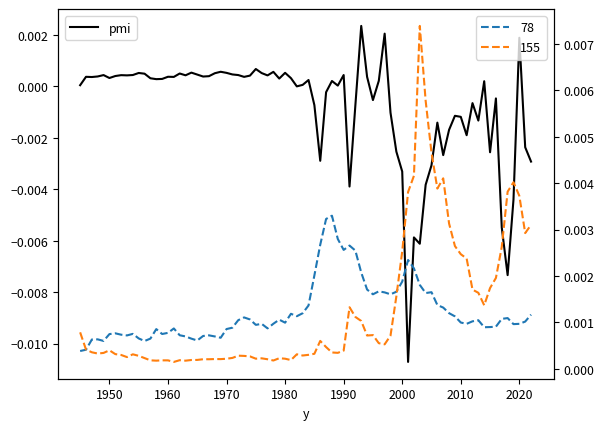

In [45]:
f,a = plt.subplots()

rd[(rd.s.str.startswith('78 ')) & (rd.t.str.startswith('155 '))].plot(x='y',y='pmi',ax =a, color="black")

a_diac = a.twinx()
diac.plot(y='78',ax=a_diac,linestyle='--')
diac.plot(y='155',ax=a_diac,linestyle='--')

In [55]:
edges = rd[(rd.s.str.startswith('78 '))].groupby(['y','t']).pmi.mean().unstack()

In [61]:
from pymannkendall import original_test as pmk

In [67]:
edges.bfill().ffill().ewm(span=12).mean().apply(lambda x: pmk(x).slope).nlargest(15)

t
36 heel gesprek goed vraag echt heer natuurlijk mevrouw                                                         0.000088
240 land minister hulp ontwikkelingsamenwerking ontwikkelingssamenwerking beleid nederlands ontwikkelingland    0.000084
38 debat kabinet fractie kamer politiek heer voorzitter coalitie                                                0.000082
446 motie regering orde dag lid beraadslaging voldoende indiening                                               0.000081
454 minister punt termijn opmerking vraag antwoord twee kamer                                                   0.000077
129 begroting post uitgave jaar bedrag kamer financiën behandeling                                              0.000075
113 motie minister kamer steun regering voorzitter dag orde                                                     0.000070
317 toezicht toezichthouder controle onafhankelijk goed wet taak financieel                                     0.000069
65 kabinet mld jaar lastenverl

In [79]:
t = '78 controle financieel verantwoording jaarverslag goed beheer doelmatigheid extern'

In [80]:
# dfd.groupby(dfd.index.year).mean().plot(y=376)

In [81]:
d = rd[rd.s==t].groupby(['y','t']).pmi.mean().unstack().bfill().ffill()

In [82]:
d = d.div(d.sum(axis=1),axis=0).ewm(span=12).mean()

# Partial Correlation

In [4]:
import numpy as np
import pandas as pd
from sklearn.covariance import GraphicalLassoCV

def clr_transform(X, eps=1e-10):
    """
    Centered log-ratio transform for compositional data.
    """
    X = X + eps  # avoid log(0)
    logX = np.log(X)
    gm = logX.mean(axis=1, keepdims=True)
    return logX - gm


def partial_corr_from_precision(precision):
    """
    Convert precision matrix to partial correlation matrix.
    """
    D = np.sqrt(np.diag(precision))
    partial_corr = -precision / np.outer(D, D)
    np.fill_diagonal(partial_corr, 1.0)
    return partial_corr


def topic_partial_correlation(df, period, topic_names=None):
    """
    Estimate partial correlations between topics for a given period.

    Parameters
    ----------
    df : pandas DataFrame
        Must contain 'date' column and topic columns.
    period : str or int
        Example: '1995' or 1995
    topic_names : dict (optional)
        Mapping from topic id to readable label.

    Returns
    -------
    DataFrame with columns: t1, t2, score
    """

    # subset to one year
    df_sub = df[pd.to_datetime(df['date']).dt.year == int(period)]

    # keep only topic columns
    topic_cols = [c for c in df_sub.columns if c != 'date']
    X = df_sub[topic_cols].values

    # CLR transform (important!)
    X_clr = clr_transform(X)

    # Estimate sparse precision matrix
    model = GraphicalLassoCV()
    model.fit(X_clr)

    precision = model.precision_
    pcor = partial_corr_from_precision(precision)

    # Build tidy output
    rows = []
    for i in range(len(topic_cols)):
        for j in range(i + 1, len(topic_cols)):
            t1 = topic_cols[i]
            t2 = topic_cols[j]

            if topic_names is not None:
                t1 = topic_names.get(t1, t1)
                t2 = topic_names.get(t2, t2)

            rows.append({
                "t1": t1,
                "t2": t2,
                "score": pcor[i, j]
            })

    return pd.DataFrame(rows)

In [31]:
pcor_1995 = topic_partial_correlation(df, 2020, topic_names=ks)

/home/rb/Documents/Code/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


In [39]:
s = pcor_1995[pcor_1995.score>.05]
s['s'] = s.t1.astype(int).map(ks)
s['t'] = s.t2.astype(int).map(ks)

/tmp/ipykernel_251866/3976429781.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s['s'] = s.t1.astype(int).map(ks)
/tmp/ipykernel_251866/3976429781.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s['t'] = s.t2.astype(int).map(ks)


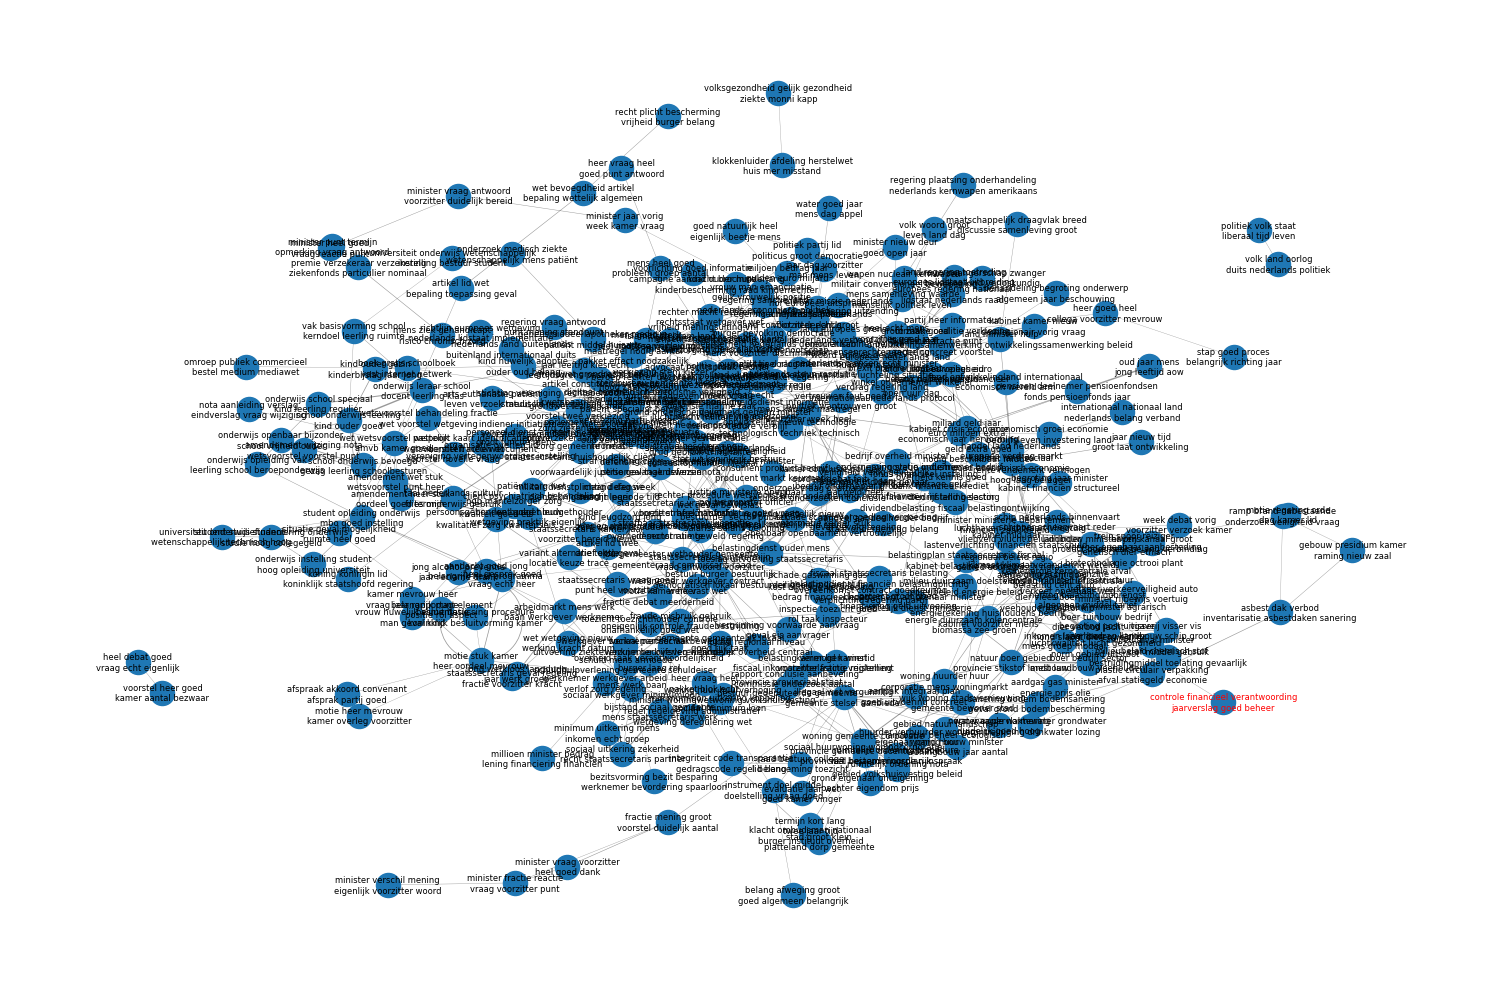

In [40]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# --- helper: top 15 words + newline every 3 words ---
def format_label(text, top_n=6, wrap_every=3):
    words = str(text).split()[:top_n]
    lines = [
        " ".join(words[i:i+wrap_every])
        for i in range(0, len(words), wrap_every)
    ]
    return "\n".join(lines)

# --- build graph ---
G = nx.Graph()

for _, row in s.iterrows():
    s_label = format_label(row['s'])
    t_label = format_label(row['t'])

    G.add_edge(s_label, t_label, weight=row.get('score', 1))

# --- layout ---
pos = nx.spring_layout(G, k=0.8, iterations=800, seed=42)

# --- plot ---
fig, ax = plt.subplots(figsize=(15, 10))

# 1️⃣ Draw edges with networkx
nx.draw_networkx_edges(
    G, pos,
    ax=ax,
    width=[G[u][v]['weight'] * 5 for u, v in G.edges()],
    alpha=0.4
)

# 2️⃣ Draw nodes manually with scatter
x_vals = [pos[node][0] for node in G.nodes()]
y_vals = [pos[node][1] for node in G.nodes()]

plt.scatter(x_vals, y_vals, s=300, zorder=3)

# 3️⃣ Annotate manually
for node, (x, y) in pos.items():
    plt.annotate(
        node,
        (x, y),
        fontsize=6,
        color='black' if node.startswith('controle') == False else 'red',
        ha='center',
        va='center'
    )

plt.axis("off")
plt.tight_layout()
plt.show()

In [43]:
from collections import Counter

In [49]:
df.groupby(pd.to_datetime(df.date).dt.year).size()

date
1945     104
1946     792
1947     966
1948     991
1949    1032
        ... 
2018    3444
2019    3419
2020    2784
2021    2986
2022    1816
Length: 78, dtype: int64

In [46]:
Counter(dict(G.degree)).most_common(15)

[('illegaal wet vergunning\ngemeente stelsel aanbieder', 19),
 ('mens heel moment\nweek vraag echt', 14),
 ('belastingdienst ouder mens\ntoeslag uitvoering staatssecretaris', 13),
 ('mens kabinet maatregel\nvoorzitter week heel', 13),
 ('zorg ziekenhuis patiënt\nzorgverzekeraar kwaliteit goed', 11),
 ('mens jaar keer\nvoorzitter echt groot', 11),
 ('handel land nederlands\neuropees verdrag markt', 10),
 ('dier vlees boer\nveehouderij sector kip', 10),
 ('kabinet land sociaal\ngoed economisch economie', 10),
 ('militair oorlog internationaal\nnederlands steun resolutie', 10),
 ('politie agent veiligheid\nstraat criminaliteit minister', 10),
 ('woning gemeente corporatie\nsociaal huurwoning woningcorporatie', 9),
 ('werknemer werkgever contract\nwerk vast wet', 9),
 ('wet wetsvoorstel wettelijk\namvb kamer goed', 9),
 ('land vluchteling mens\nopvang asielzoeker regio', 9)]